### Gini

Gini Index:
$$Gini(S) = 1 - \sum_{i=1}^{c} (p_i)^2$$

General Gini:
$$Gini_{split} = \frac{|S_{left}|}{|S|} Gini(S_{left}) + \frac{|S_{right}|}{|S|} Gini(S_{right})$$

$Gini = 1 - ((6/8)^2 + (2/8)^2) = 0.375$

$Gini = 1 - ((3/6)^2 + (3/6)^2) = 0.5$

$$Gini_{Wind} = \frac{8}{14} \cdot 0.375 + \frac{6}{14} \cdot 0.5 \approx \mathbf{0.428}$$

$$Gini_{Outlook} = \left( \frac{5}{14} \cdot 0.48 \right) + \left( \frac{4}{14} \cdot 0 \right) + \left( \frac{5}{14} \cdot 0.48 \right)\approx \mathbf{0.3428}$$


<font color = green >

# Decision Trees
</font>

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [12]:
%matplotlib inline 

<font color = green >

## Iris dataset 
</font>

In [13]:
# Don't install graphviz with the help of pip, use conda install  graphviz
# !pip install graphviz

In [14]:
# !conda install graphviz

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# Note: In case of RuntimeError "Make sure the Graphviz executables are on your system's path” after installing Graphviz 
# helps on mac:  brew install graphviz
# helps on windows:  import os
# os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz2.38\bin'

In [16]:
max_depth = 3
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,        
    max_depth=max_depth,    
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

NameError: name 'DecisionTreeClassifier' is not defined

In [42]:
max_depth = 2
clf = DecisionTreeClassifier(
    criterion=  'gini',
    random_state=20,        
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 94.737%


<font color = green >

## Vizualize the decision tree  graph 
</font>

In [43]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=features,  
                                class_names=labels,  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

display(graph)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

<font color = green >

## Feature importance
</font>

In [44]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

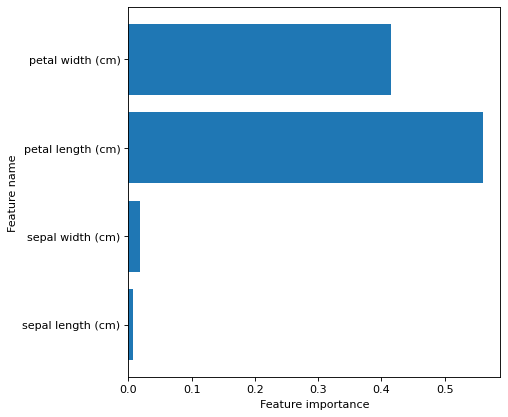

In [45]:
plot_feature_importances(clf, features)

<font color = green >

## Regressor
</font>

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [48]:
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=10).fit(X_train, y_train)

<font color = green >

## Auxiliary drawing functions 
</font>

<font color = green >

## Synthetic dataset
</font>

In [2]:
from sklearn.datasets import make_blobs

<font color = green >

## Tennis dataset

</font>

In [93]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'tennis.csv')
fn=  'data/tennis.csv'
df = pd.read_csv(fn)
del df['temp']
print (df.head())

X_train = df.iloc[:, :3].values
y_train = df.iloc[:, 3].values
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)

    outlook humidity   wind play
0     sunny     high  False   no
1     sunny     high   True   no
2  overcast     high  False  yes
3     rainy     high  False  yes
4     rainy   normal  False  yes

X_train.shape=  (14, 3)
y_train.shape=  (14,)


In [94]:
from sklearn.preprocessing  import LabelEncoder

In [95]:
X_train_cat = X_train.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print ('{}: {}'.format(list(df)[i], le_dict))
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

outlook: {'overcast': 0, 'rainy': 1, 'sunny': 2}
humidity: {'high': 0, 'normal': 1}
wind: {False: 0, True: 1}
y:  {'no': 0, 'yes': 1}
X_train_cat.shape=  (14, 3)
y_train_cat.shape=  (14,)


array([[2, 0, 0],
       [2, 0, 1],
       [0, 0, 0],
       [1, 0, 0],
       [1, 1, 0],
       [1, 1, 1],
       [0, 1, 1],
       [2, 0, 0],
       [2, 1, 0],
       [1, 1, 0],
       [2, 1, 1],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 1]], dtype=object)

In [96]:
max_depth = None
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,        
    max_depth=max_depth,    
    # max_leaf_nodes=4,
).fit(X_train_cat, y_train_cat)
features = list(df)[:3]
labels = ['No','Yes']

print("train accuracy= {:.3%}".format(clf.score (X_train_cat, y_train_cat)))

train accuracy= 100.000%


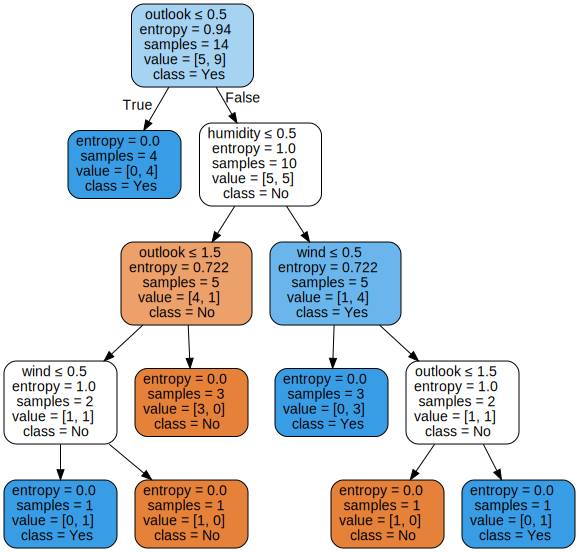

In [97]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=list(features),  
                                class_names=[str(l) for l in labels],  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

display(graph)

<font color = green>

#  Random Forests

</font>



In [98]:
from sklearn.ensemble import RandomForestClassifier

<font color = green>

## Iris dataset

</font>



In [99]:
iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

X.shape=  (150, 4)
y.shape=  (150,)
X_train.shape=  (112, 4)
X_test.shape=  (38, 4)
y_train.shape=  (112,)
y_test.shape=  (38,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names : {0: 'setosa', 1: 'versicolor', 2: 'virginica'}


In [100]:
clf = RandomForestClassifier().fit (X_train, y_train)
clf.score (X_train, y_train)
n_estimators_list= [5,10,20]
max_features_list= list(np.arange(1, X_train.shape[1]+1))

for i in range (len(n_estimators_list)): 
    for j in range (len(max_features_list)):
        index = len(max_features_list)*i+j           
        clf = RandomForestClassifier(
            random_state=10,
            n_estimators= n_estimators_list[i],
            max_features=max_features_list[j],        
        ).fit(X_train, y_train)
        accuracy_train = clf.score (X_train, y_train)
        accuracy_test = clf.score (X_test, y_test)
        print ('n_estimators= {}, max_features = {}, accuracy_train = {:.3%}, accuracy_test = {:.3%}'.format (
            n_estimators_list[i],max_features_list[j], accuracy_train, accuracy_test))

n_estimators= 5, max_features = 1, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 2, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 3, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 4, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 10, max_features = 1, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 10, max_features = 2, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 10, max_features = 3, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 10, max_features = 4, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 20, max_features = 1, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 20, max_features = 2, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 20, max_features = 3, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 20, max_features = 4, accuracy_train 

In [101]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test, y_test)))

--- RANDOM FOREST RESULTS (ENSEMBLE) ---
Train accuracy (RF) = 97.321%
Test accuracy (RF) = 97.368%

--- DECISION TREE RESULTS (SINGLE TREE) ---
Train accuracy (DT) = 98.214%
Test accuracy (DT) = 97.368%


In [ ]:
# Conclusion: this dataset is not good to demonstrate the power of random forest 

<font color = green>

## Mushrooms dataset

</font>



In [102]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'mushrooms.csv')
fn= 'data/mushrooms.csv'
# https://www.kaggle.com/ymotonskillupai/mushroomscsv
df = pd.read_csv(fn)

print (list(df))
X = df.iloc[:, 1:].values
y = df.iloc[:, 1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)
df.head()

['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

X_train.shape=  (6093, 22)
y_train.shape=  (6093,)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [103]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print (X_test[:,i])
    X_test_cat[:,i] = le.transform(X_test[:,i])
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
y_test_cat= le.transform(y_test)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

['x' 'f' 'x' ... 'x' 'x' 'k']
['y' 'y' 'y' ... 'y' 's' 's']
['n' 'g' 'y' ... 'e' 'y' 'n']
['t' 't' 't' ... 'f' 't' 'f']
['p' 'n' 'a' ... 's' 'l' 'n']
['f' 'f' 'f' ... 'f' 'f' 'a']
['c' 'c' 'c' ... 'c' 'c' 'c']
['n' 'b' 'b' ... 'n' 'b' 'b']
['p' 'p' 'k' ... 'b' 'k' 'y']
['e' 't' 'e' ... 't' 'e' 'e']
['e' 'b' 'c' ... '?' 'c' '?']
['s' 's' 's' ... 's' 's' 's']
['s' 's' 's' ... 'k' 's' 's']
['w' 'g' 'w' ... 'p' 'w' 'o']
['w' 'g' 'w' ... 'p' 'w' 'o']
['p' 'p' 'p' ... 'p' 'p' 'p']
['w' 'w' 'w' ... 'w' 'w' 'n']
['o' 'o' 'o' ... 'o' 'o' 'o']
['p' 'p' 'p' ... 'e' 'p' 'p']
['k' 'k' 'n' ... 'w' 'k' 'b']
['s' 'y' 'n' ... 'v' 's' 'c']
['u' 'd' 'm' ... 'd' 'g' 'l']
y:  {'b': 0, 'c': 1, 'f': 2, 'k': 3, 's': 4, 'x': 5}
X_train_cat.shape=  (6093, 22)
y_train_cat.shape=  (6093,)


array([[2, 3, 9, ..., 1, 5, 1],
       [5, 3, 4, ..., 3, 5, 1],
       [2, 2, 3, ..., 2, 0, 1],
       ...,
       [5, 2, 3, ..., 3, 3, 1],
       [2, 0, 4, ..., 3, 4, 0],
       [5, 3, 3, ..., 3, 5, 0]], dtype=object)

In [104]:
max_features_list = [20,12, 10,8,6,4,3,2,1]    
for i, max_features in enumerate(max_features_list):
    clf = RandomForestClassifier(
        random_state=0,        
        max_features= max_features,    
    ).fit(X_train_cat, y_train_cat)
    accuracy_train = clf.score(X_train_cat, y_train_cat)
    accuracy_test = clf.score(X_test_cat, y_test_cat)
    print ('max_features = {}:\n\t accuracy_train = {:.3%}\n\t accuracy_test = {:.3%}'.format (
        max_features_list[i], accuracy_train, accuracy_test))

max_features = 20:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 12:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 10:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 8:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 6:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 4:
	 accuracy_train = 100.000%
	 accuracy_test = 99.951%
max_features = 3:
	 accuracy_train = 100.000%
	 accuracy_test = 99.754%
max_features = 2:
	 accuracy_train = 100.000%
	 accuracy_test = 99.606%
max_features = 1:
	 accuracy_train = 100.000%
	 accuracy_test = 99.360%


In [105]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth,
).fit(X_train_cat, y_train_cat)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train_cat, y_train_cat)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test_cat, y_test_cat)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train_cat, y_train_cat)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train_cat, y_train_cat)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test_cat, y_test_cat)))

--- RANDOM FOREST RESULTS (ENSEMBLE) ---
Train accuracy (RF) = 94.371%
Test accuracy (RF) = 93.550%

--- DECISION TREE RESULTS (SINGLE TREE) ---
Train accuracy (DT) = 99.951%
Test accuracy (DT) = 99.951%


In [ ]:
# Conclusion: this dataset is also  not good to demonstrate the power of random forest :)

<font color = green >

# Gradient boosting decision tree
</font>

In [106]:
from sklearn.ensemble import GradientBoostingClassifier

<font color = green>

## Fruits dataset 2D

</font>



In [107]:
import os
cwd= os.getcwd() 
path = os.path.join(cwd,'data')
fn=  os.path.join(path , 'fruit_data_with_colors.txt')
df_fruits = pd.read_table(fn)
df_fruits.head(10)


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81
8,1,apple,braeburn,178,7.1,7.8,0.92
9,1,apple,braeburn,172,7.4,7.0,0.89


In [108]:
def plot_decision_boundary_universal(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.1,plot_symbol_size = 50, ax= None,  is_extended=True, labels= None, features =None):
    '''
    expected to be universal for binary and multiclass classification but not tested for binary 
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_areas= colors_for_points =  np.array(['green','grey', 'orange', 'brown'])
    cmap_light = ListedColormap(colors_for_areas)

    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])
    if precision<0.05:
        print ('Calling to predict for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        
        # Create legend
        if labels is None:
            labels= ['negative','positive'] # assume this is for binary or for muticlass with labels 
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patches= [mpatches.Patch(color=colors_for_points[i], label=labels[i]) for i in range (len(labels))]
        plt.legend(handles=patches)
        if features is None:
            plt.xlabel('feature 1')
            plt.ylabel('feature 2')
        else: 
            plt.xlabel(features[0])
            plt.ylabel(features[1])

    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )
    plt.title(title)


X_train.shape=  (44, 2)
X_test.shape=  (15, 2)
y_train.shape=  (44,)
y_test.shape=  (15,)
target names : {0: 'apple', 1: 'mandarin', 2: 'orange', 3: 'lemon'}


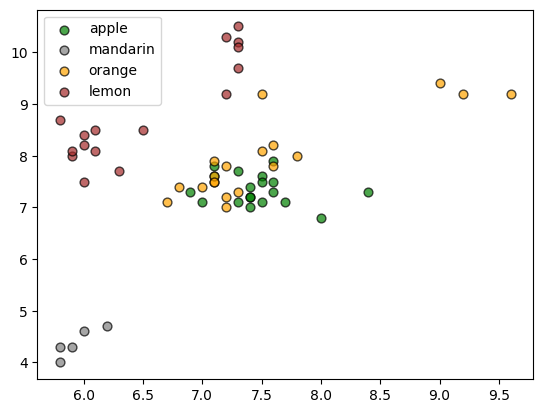

In [109]:
features = ['width', 'height']
X = df_fruits[features].values
y = df_fruits['fruit_label'].values -1  # shift due to labels of fruits are from 1 

df_fruits.head(20)
# labels =  df_fruits['fruit_name'].unique()
fruits_dict = dict(zip(np.unique(y), df_fruits['fruit_name'].unique()))

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)

print ('target names :', fruits_dict)

plt.figure()
plot_multi_class_logistic_regression (X,y,dict_names=fruits_dict)


train accuracy= 95.455%
test accuracy= 80.000%


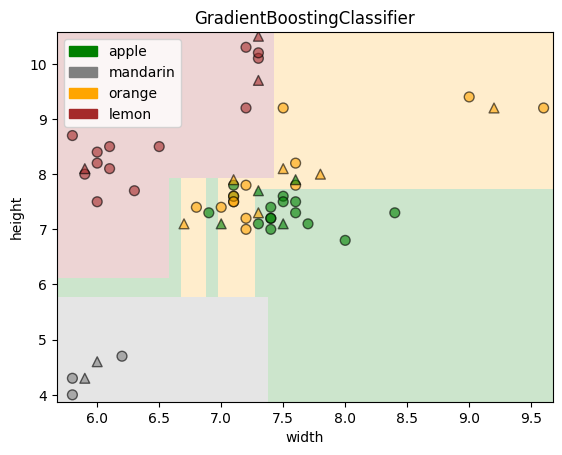

In [110]:
plt.figure ()
labels =list(fruits_dict.values())

clf = GradientBoostingClassifier(learning_rate=0.01,max_depth=3).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
plot_decision_boundary_universal(clf, X_train, y_train, X_test, y_test, title='GradientBoostingClassifier', precision=0.05, labels= labels, features = features)


---

<font color = green>

##  XGBoost
</font>



In [ ]:
!pip install XGBoost

In [111]:
from xgboost import XGBClassifier

clf_xgboost = XGBClassifier(use_label_encoder=False, eval_metric= 'logloss')
clf_xgboost.fit(X_train, y_train)
print('\nAccuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf_xgboost.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf_xgboost.score(X_test, y_test)))




Accuracy of Logistic regression classifier on training set: 0.98
Accuracy of Logistic regression classifier on test set: 0.67


In [112]:
help(XGBClassifier)

Help on class XGBClassifier in module xgboost.sklearn:

class XGBClassifier(XGBModel, sklearn.base.ClassifierMixin)
 |  XGBClassifier(*, objective: Union[str, Callable[[numpy.ndarray, numpy.ndarray], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic', use_label_encoder: bool = False, **kwargs: Any) -> None
 |  
 |  Implementation of the scikit-learn API for XGBoost classification.
 |  
 |  
 |  Parameters
 |  ----------
 |  
 |      n_estimators : int
 |          Number of boosting rounds.
 |  
 |      max_depth :  Optional[int]
 |          Maximum tree depth for base learners.
 |      max_leaves :
 |          Maximum number of leaves; 0 indicates no limit.
 |      max_bin :
 |          If using histogram-based algorithm, maximum number of bins per feature
 |      grow_policy :
 |          Tree growing policy. 0: favor splitting at nodes closest to the node, i.e. grow
 |          depth-wise. 1: favor splitting at nodes with highest loss change.
 |      learning_rate : 

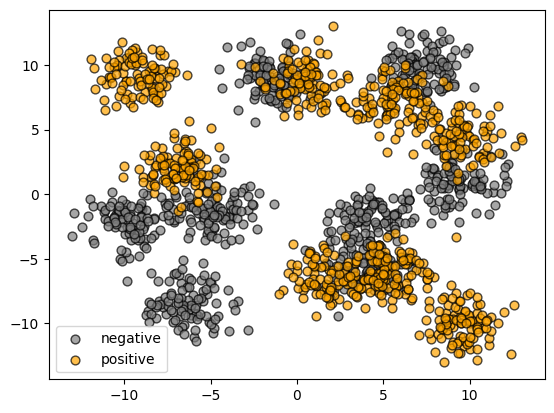

In [113]:
X_mk8, y_mk8 = make_blobs(n_samples = 2000, n_features = 2, centers = 16, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X = X_mk8
y = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
plt.figure()
plot_data_logistic_regression(X_train,y_train)

In [114]:
print(X_train.shape)
y_train.shape

(1500, 2)


(1500,)

In [115]:
X_train

array([[ -7.11271763,  -2.18572036],
       [  9.04587707, -11.46625813],
       [ -4.37859762,   1.69193429],
       ...,
       [  5.26290094,  -5.6390031 ],
       [  1.0183784 ,  -6.95986805],
       [ -6.21752906,  -0.20391296]])

In [116]:
common_max_depth = 3
seed = 10

print('='*30)
print('DECISION TREE')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=seed,        
    max_depth=common_max_depth
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_dt.score(X_test, y_test)))

print('\n' + '='*30)
print('RANDOM FOREST')
clf_rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n' + '='*30)
print('GRADIENT BOOSTING')
clf_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_gb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_gb.score(X_test, y_test)))

print('\n' + '='*30)
print('XGBOOST')
clf_xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss',
    n_estimators=100,
    max_depth=common_max_depth, 
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_xgb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_xgb.score(X_test, y_test)))

DECISION TREE
Train accuracy = 82.267%
Test accuracy  = 78.400%

RANDOM FOREST
Train accuracy = 85.800%
Test accuracy  = 80.200%

GRADIENT BOOSTING
Train accuracy = 91.667%
Test accuracy  = 83.000%

XGBOOST
Train accuracy = 94.000%
Test accuracy  = 83.400%


<font color = green >
    
# Home Task 

</font>



<font color = green>

##  Brest cancer  dataset
</font>



In [10]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


<font color = green>

##  DecisionTree 

</font>



In [57]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=4, random_state=0)
clf.fit(X_train, y_train)

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 99.296%
test accuracy= 90.210%


<font color = green>

##  RandomForest

</font>



In [17]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0)
clf.fit(X_train, y_train)

print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

train accuracy= 99.296%
test accuracy= 97.203%


<font color = green>

##  Gradient Boosting Decision Trees (GBDT)

</font>



In [19]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=0
)

clf.fit(X_train, y_train)

print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

train accuracy= 98.826%
test accuracy= 96.503%


<font color = green>

##  XGBoost

</font>



In [18]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    eval_metric='logloss',
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

clf.fit(X_train, y_train)

print("train accuracy: {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy: {:.3%}".format(clf.score(X_test, y_test)))

train accuracy: 98.592%
test accuracy: 97.203%


# Additional tasks

### 1) Binary Classification:
    Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

### 2) Regression:
    Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

_____________________________________________________________________________________________________________________________________________________________________________________________________________________

## Assessment Criteria and Requirements

I will evaluate the entire process of working on your project—from the moment you load the dataset to the final result. Your task is to apply all the knowledge you have gained in lectures up to this point.

There is no minimum accuracy threshold: the main focus will be on the quality of implementation. However, if the model’s accuracy is too low, the assignment may not be accepted.

In [54]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Classification:

In [7]:
data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame
df_income

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# Regression:

In [8]:
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
df_house

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
